## ForestYieldML: A Comparative Regression Study for Plantation Growth Prediction Using PSP Data

## Import all the relevant libraries

In [1]:
# Database connection (Postgres database)
import psycopg2
from sqlalchemy import create_engine

import numpy as np # for numerical computations
import pandas as pd # provide data structures for handling structured data (tabular data)
# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Query Database to Extract Relevant Data

In [2]:
# Connection parameters
DB_USER = 'postgres'
DB_PASSWORD = 'gogilbert9812806'
DB_NAME = 'psp_db'
DB_HOST = 'localhost'
DB_PORT = '5432'

In [3]:
# Connection string
conn_str = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

In [4]:
# Constructive query to retrieve the required data
# What this query does is that, it joins four (4) tables on various columns to 
# retrieve the data
# The query is to extract the information on only teak plants.

query = """
    SELECT
        b.plantation,
        p.block,
        b."year planted",
        p.plot,
        pmh."Default plot size",
        pmh."Plot type",
        d.area_type,
        d."monitoring year",
        d.tree_id,
        d."Tree SPECIES",
        d.height_m,
        d.dbh_cm,
        d.remarks
    FROM block_register b
    JOIN plot_block_relation p
        ON b.plantation = p.plantation
        AND b.block = p.block
    JOIN plot_monitoring_history pmh
        ON pmh.plantation = p.plantation
        AND pmh.plot = p.plot
    JOIN treedata d
        ON b.plantation = d.plantation
        AND d.plot = p.plot
        AND d.area_type = 'Teak';
    
"""

In [5]:
# Use pandas to extract the data into dataframe
df = pd.read_sql_query(query, engine)

In [6]:
# Snapshot of the data
df.head()

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8577780 entries, 0 to 8577779
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   plantation         object 
 1   block              object 
 2   year planted       int64  
 3   plot               object 
 4   Default plot size  float64
 5   Plot type          object 
 6   area_type          object 
 7   monitoring year    float64
 8   tree_id            float64
 9   Tree SPECIES       object 
 10  height_m           float64
 11  dbh_cm             float64
 12  remarks            object 
dtypes: float64(5), int64(1), object(7)
memory usage: 850.8+ MB


In [8]:
# Dataset shape
df.shape

(8577780, 13)

In [9]:
# Check for null values in height and dbh
df[['height_m', 'dbh_cm']].isna().sum()

height_m     4788
dbh_cm      11404
dtype: int64

In [10]:
df.dropna(subset=['height_m', 'dbh_cm'], inplace=True)

In [11]:
df[['height_m', 'dbh_cm']].isna().sum()

height_m    0
dbh_cm      0
dtype: int64

In [12]:
df['remarks'].unique()

array(['Fire scars', None, 'Beetle infestation', 'Top broken', 'Coppice',
       'Broken top', 'Forked', 'Dead tree', 'Forked at 30 cm',
       'Fork at 2m', 'Nearly dead', '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'Wildling',
       'Outside planting line - Wildling', 'marked',
       'bark damaged by termites', 'Dead tree - marked',
       'Has leaves to about 6m', 'dead tree, but resprouting',
       'Sapling - Wildling', 'Black ant attack from base to top',
       'dead tree, but coppicing', 'Old teak stand', 'Double stem',
       '3 stems', 'The tree is highly branched at this height sideways',
       'Dying', 'ceber', 'Main tree dead', 'Top dead', '', 'Beaten-up',
       'Taken with metre tape', 'DBH taken with metre tape',
       'Forked at DBH, taken above', 'No leaves, but alive',
       'Taken with metre tape.', 'Diseased', 'top slashed',
       'Teak dieback', 'Dbh taken with metre tape', 'Top dead - Wildling',
       'Circumference', 'Beate

In [13]:
# List of unwanted data
unwanted = r"(Wildling|Coppice|Broken top|diseased|dead|Top broken|coppice|wildling|fork|Beetle|Old|dieback|die back|Dying|Diseased|Broken|Abnormal|crooked|marked)"

# Remove the unwanted values based on the remarks
mask = df['remarks'].str.contains(unwanted, case=False, na=False)
df = df[~mask]

C:\Users\GILBERT FG\AppData\Local\Temp\ipykernel_3076\4140006.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['remarks'].str.contains(unwanted, case=False, na=False)


In [14]:
# Verify if the unwanted values are removed
df['remarks'].unique()

array(['Fire scars', None, '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'bark damaged by termites',
       'Has leaves to about 6m', 'Black ant attack from base to top',
       'Double stem', '3 stems',
       'The tree is highly branched at this height sideways', 'ceber', '',
       'Beaten-up', 'Taken with metre tape', 'DBH taken with metre tape',
       'No leaves, but alive', 'Taken with metre tape.', 'top slashed',
       'Dbh taken with metre tape', 'Circumference',
       'Beaten-up. Top slashed', 'Sunto', 'sunto', '2012 teak',
       '2012 teak, top slashed', '2012 burnt teak', 'already planted',
       'Diameter taken with diameter tape', 'Tape',
       'Hole in it. Diameter taken with diameter tape',
       'Measured with diameter tape. Diameter taken with diameter tape',
       'Diameter < 0. Diameter taken with diameter tape',
       'diseasesed - Diameter taken with diameter tape',
       'No DHB entered. Diameter taken with diameter tape. DB

In [15]:
# Check for any unwanted tree species in the data
df['Tree SPECIES'].unique()

array(['Teak', 'York', 'onyono', 'Mahogany', None, 'Albizia',
       'Awiemfosamina', 'Kyenkyen', 'Sofo', 'Onyina', 'Cassia', 'Wawa',
       'Unknown indigenous', 'Asanfena', 'Hontan', 'Akuakuo-Ninsuo',
       'Okoro', 'Nyankyerene', 'Watapuo', 'Akonkodie', 'Mango',
       'kwakuanisuo', 'Hyedua', 'Nyamedua', 'kotrenfro', 'Ofram',
       'Konkroma', 'Cedrela', 'Khaya ivorensis', 'Albizia adianthifolia',
       'Kane', 'Wama', 'Wonton', 'Odum', 'Trilepisium madagascariense',
       'Tetrapleura tetraptera', 'Kusia', 'Okure', 'Foto', 'Womba',
       'Alstonia boonei', 'Anacardium occidentale', 'Afzelia', 'Otie',
       'coconisuol', 'prekese', 'Kotreamfo', 'Acacia', 'Akye', 'Nofotene',
       'Acasia', 'Kigelia africana', 'Prekese', 'Kookonisuo'],
      dtype=object)

In [17]:
# Remove any unwanted tree species
df = df[(df['Tree SPECIES'].str.lower() == 'teak')]

In [18]:
# Verify
df['Tree SPECIES'].unique()

array(['Teak'], dtype=object)

In [19]:
df.shape

(8038356, 13)

In [21]:
df[['height_m', 'dbh_cm']].describe()

,height_m,dbh_cm
count,8.038356e+06,8.038356e+06
mean,9.499586e+00,1.164350e+01
std,4.918124e+00,6.937685e+00
min,0.000000e+00,0.000000e+00
25%,5.770000e+00,6.250000e+00
50%,1.000000e+01,1.180000e+01
75%,1.325000e+01,1.660000e+01
max,3.725000e+01,5.270000e+01


<Axes: xlabel='dbh_cm', ylabel='height_m'>

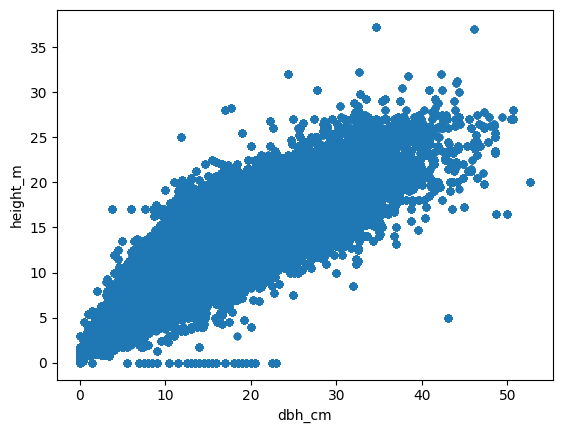

In [31]:
# Relationship of height and diameter
df.plot.scatter('dbh_cm', 'height_m')

In [33]:
# remove trees with hd ratio less than 30
df = df[~(df['hd_ratio'] < 30)]

In [36]:
# remove trees with zero dbh
df = df[~(df['dbh_cm'] == 0.0)]

In [37]:
# remove trees with zero height
df = df[~(df['height_m'] == 0.0)]

In [38]:
df.shape

(7470656, 14)

<Axes: xlabel='dbh_cm', ylabel='height_m'>

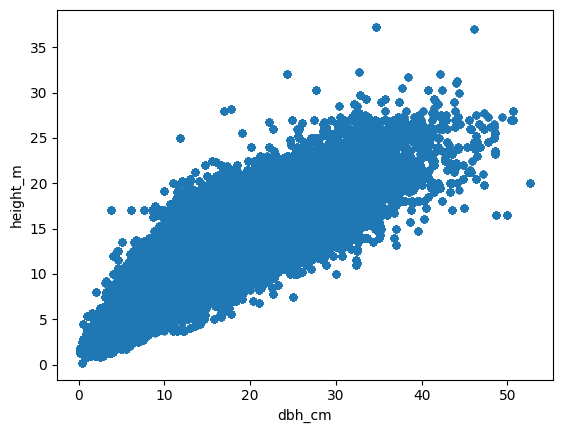

In [39]:
df.plot.scatter('dbh_cm', 'height_m')

<Axes: >

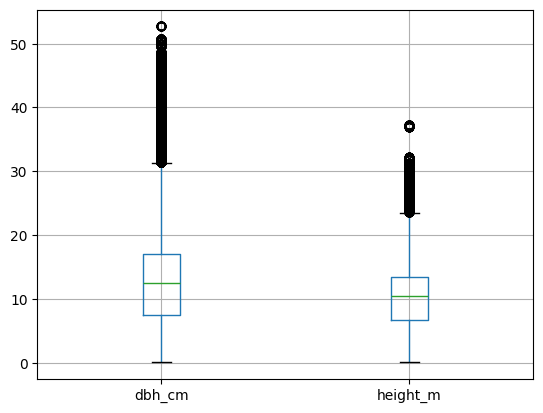

In [40]:
# check for outliers
df[['dbh_cm', 'height_m']].boxplot()

### DISTRIBUTIONS

Text(0.5, 0, 'DBH (cm)')

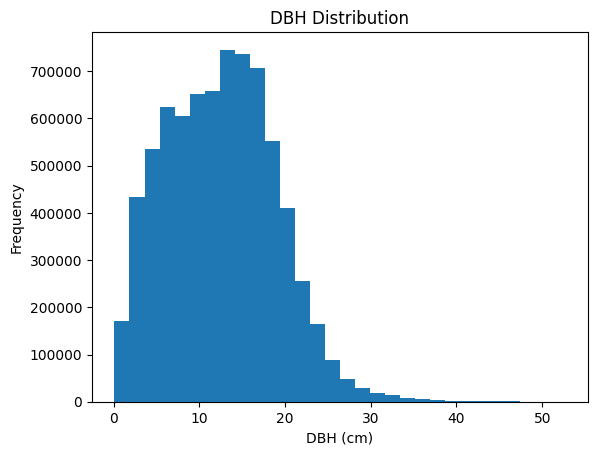

In [41]:
# DBH distribution
df['dbh_cm'].plot.hist(bins=30, title='DBH Distribution')
plt.xlabel('DBH (cm)')

Text(0.5, 0, 'Height (m)')

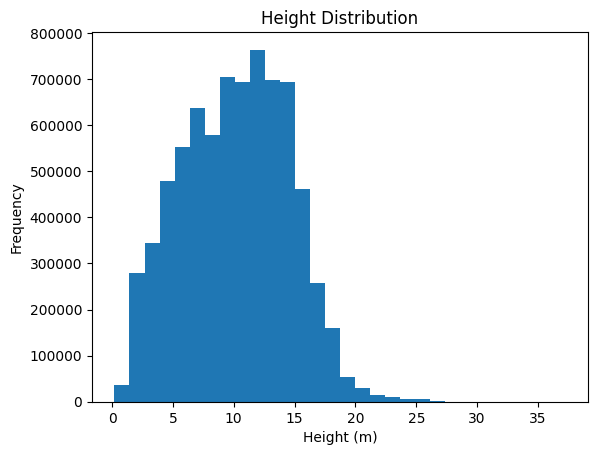

In [47]:
# Height Distribution
df['height_m'].plot.hist(bins=30, title='Height Distribution')
plt.xlabel('Height (m)')

### Derived Features

In [48]:
# Tree Ages
df['Age'] = df['monitoring year'] - df['year planted']
df.head(5)

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age
0,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
1,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
2,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
3,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
4,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0


In [49]:
# Basal Area (m2)
df['basal_area_m2'] = (np.pi * (df['dbh_cm']/100)**2)/4

In [50]:
df.head()

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area_m2
0,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
1,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
2,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
3,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
4,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131


In [51]:
# Compute Tree Volume
form_factor = 0.5 # This is estimate value. Replace with the actual form factor
df['volume_m3'] = df['basal_area_m2'] * df['height_m'] * form_factor

In [52]:
df.head()

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area_m2,volume_m3
0,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
1,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
2,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
3,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
4,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998


In [87]:
df_tain_ii = df[(df['plantation'] == 'Tain II')]
df_tain_ii.head()

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area_m2,volume_m3
0,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
1,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
2,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
3,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998
4,Tain II,B39,2013,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.040998


In [88]:
df_tain_ii.shape

(3366724, 17)

In [89]:
df_tain_ii['monitoring year'].unique()

array([2018., 2019., 2020., 2021., 2023., 2022., 2024.])

In [90]:
# Analyzing 2024 monitoring year for Tain II
df_2024 = df_tain_ii[(df_tain_ii['monitoring year'] == 2024.0)]
df_2024.head()

,plantation,block,year planted,plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,Age,basal_area_m2,volume_m3
4096542,Tain II,B64,2015,544,729.0,Square,Teak,2024.0,1.0,Teak,14.0,13.5,,103.703704,9.0,0.014314,0.100197
4096543,Tain II,B64,2015,544,729.0,Square,Teak,2024.0,1.0,Teak,14.0,13.5,,103.703704,9.0,0.014314,0.100197
4096544,Tain II,B64,2015,544,729.0,Square,Teak,2024.0,1.0,Teak,14.0,13.5,,103.703704,9.0,0.014314,0.100197
4096545,Tain II,B64,2015,544,729.0,Square,Teak,2024.0,1.0,Teak,14.0,13.5,,103.703704,9.0,0.014314,0.100197
4096546,Tain II,B64,2015,544,729.0,Square,Teak,2024.0,1.0,Teak,14.0,13.5,,103.703704,9.0,0.014314,0.100197


In [91]:
df_2024.shape

(253548, 17)

In [111]:
# volume per hectare per block
block_vol_2024 = df_2024.groupby(['block', 'plot', 'Default plot size'])['volume_m3'].sum().reset_index(name='total_volume')
block_vol_2024.head()


,block,plot,Default plot size,total_volume
0,A27,686,729.0,71.192636
1,A27,687,729.0,127.240024
2,A27,688,729.0,131.575068
3,A27,689,729.0,126.382649
4,A27,690,729.0,140.029600


In [113]:
block_vol_2024['plot_size_ha'] = block_vol_2024['Default plot size'] / 10000
block_vol_2024.head()

,block,plot,Default plot size,total_volume,plot_size_ha
0,A27,686,729.0,71.192636,0.0729
1,A27,687,729.0,127.240024,0.0729
2,A27,688,729.0,131.575068,0.0729
3,A27,689,729.0,126.382649,0.0729
4,A27,690,729.0,140.029600,0.0729


In [114]:
block_vol_2024['volume_per_ha'] = block_vol_2024['total_volume'] / block_vol_2024['plot_size_ha']
block_vol_2024.head()

,block,plot,Default plot size,total_volume,plot_size_ha,volume_per_ha
0,A27,686,729.0,71.192636,0.0729,976.579370
1,A27,687,729.0,127.240024,0.0729,1745.404991
2,A27,688,729.0,131.575068,0.0729,1804.870621
3,A27,689,729.0,126.382649,0.0729,1733.644014
4,A27,690,729.0,140.029600,0.0729,1920.844991


In [115]:
block_vol_2024 = block_vol_2024.groupby(['block'])['volume_per_ha'].mean().reset_index()
block_vol_2024.head()

,block,volume_per_ha
0,A27,1442.499622
1,A28,1275.630584
2,A29,1880.271136
3,A30,2289.484552
4,A31,1309.532079


In [136]:
# Volume per hectare per block for each monitoring year
block_vol = df_tain_ii.groupby(['monitoring year','block', 'plot', 'Default plot size'])['volume_m3'].sum().reset_index(name="total_volume")
block_vol.head()

,monitoring year,block,plot,Default plot size,total_volume
0,2018.0,A41A,530,729.0,3.727612
1,2018.0,A41A,531,729.0,3.183965
2,2018.0,A41A,532,729.0,43.340658
3,2018.0,A41A,533,729.0,0.168708
4,2018.0,A41B,534-old,729.0,0.008899


In [137]:
block_vol = block_vol[~(block_vol['plot'] == '534-old')]

In [138]:
block_vol.head()

,monitoring year,block,plot,Default plot size,total_volume
0,2018.0,A41A,530,729.0,3.727612
1,2018.0,A41A,531,729.0,3.183965
2,2018.0,A41A,532,729.0,43.340658
3,2018.0,A41A,533,729.0,0.168708
5,2018.0,A41B,535,729.0,0.040025


In [139]:
block_vol['plot_size_ha'] = block_vol['Default plot size'] / 10000
block_vol.head()

,monitoring year,block,plot,Default plot size,total_volume,plot_size_ha
0,2018.0,A41A,530,729.0,3.727612,0.0729
1,2018.0,A41A,531,729.0,3.183965,0.0729
2,2018.0,A41A,532,729.0,43.340658,0.0729
3,2018.0,A41A,533,729.0,0.168708,0.0729
5,2018.0,A41B,535,729.0,0.040025,0.0729


In [140]:
block_vol['volume_per_ha'] = block_vol['total_volume'] / block_vol['plot_size_ha']
block_vol.head()

,monitoring year,block,plot,Default plot size,total_volume,plot_size_ha,volume_per_ha
0,2018.0,A41A,530,729.0,3.727612,0.0729,51.133224
1,2018.0,A41A,531,729.0,3.183965,0.0729,43.675791
2,2018.0,A41A,532,729.0,43.340658,0.0729,594.522053
3,2018.0,A41A,533,729.0,0.168708,0.0729,2.314241
5,2018.0,A41B,535,729.0,0.040025,0.0729,0.549044


In [141]:
block_vol_dd = block_vol.groupby(['monitoring year', 'block'])['volume_per_ha'].mean().reset_index()
block_vol_dd.head()

,monitoring year,block,volume_per_ha
0,2018.0,A41A,172.911327
1,2018.0,A41B,7.803750
2,2018.0,A43A,105.343731
3,2018.0,A43B,77.165132
4,2018.0,A44,84.515100


In [142]:
# Volume per hectare per block for each year
block_vol_yr = block_vol.groupby('monitoring year')['volume_per_ha'].mean().reset_index()
block_vol_yr.head()

,monitoring year,volume_per_ha
0,2018.0,218.403678
1,2019.0,379.859890
2,2020.0,602.380847
3,2021.0,951.113249
4,2022.0,1031.502771


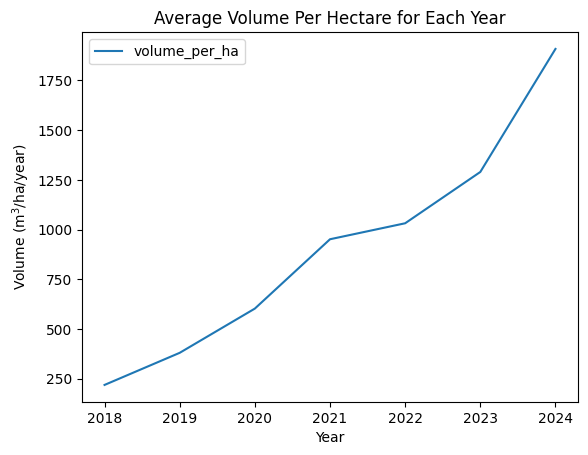

In [143]:
block_vol_yr.plot('monitoring year', 'volume_per_ha')

plt.xlabel('Year')
plt.ylabel('Volume (m$^3$/ha/year)')
plt.title('Average Volume Per Hectare for Each Year')

plt.show()